# Практическая работа №4.1. Облако смысла: количественный и визуальный анализ текста

<a id=content></a>
### Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации (файл *.txt ~ 200 Кб)</b>](#1)
2. [<b>Удалите стоп-слова и знаки препинания</b>](#2)
3. [<b>Реализуйте алгоритм предварительной обработки данных, который подсчитывает количество вхождений слов, создание датафрейма `Слово | Количество | Ранг | Процент`</b>](#3)
   <br>[3.1. Подсчёт количества вхождений слова](#3.1.)
   <br>[3.2. Создание датафрейма `Слово | Количество | Ранг | Процент`](#3.2.)
5. [<b>Анализ динамики клиентской активности и удержания</b>](#4)
    <br>[4.1. Создаём `столбчатую диаграмму` количества вхождений слов из текста](#4.1.)
    <br>[4.2. Создаём `TreeMap`](#4.2.)
    <br>[4.3. Создаём и визуализируем `Word Cloud`](#4.3.)
6. [<b>Выводы</b>](#5)

<a id=descr_proj></a>
### Описание проекта
Требуется провести глубокий анализ неструктурированного текстового документа с целью выявления ключевых лексических единиц и их роли в общем содержании. Необходимо загрузить самостоятельно выбранный текстовый файл весом до 200 Кб и получить базовую информацию о его структуре, выполнить очистку текста, рассчитать частоту вхождений каждого оставшегося слова, на основе которого сформировать упорядоченный датафрейм, содержащий не только количество вхождений, но и ранг каждого слова по популярности, а также его долю в процентах от общего числа слов. На основае полученных данных создать `столбчатую диаграмму`, `TreeMap` и `Word Cloud`, чтобы сформировать наглядное представление о том, какие слова доминируют в тексте и как они соотносятся друг с другом по частоте употребления. Иными словами, предстоит превратить сырые текстовые данные в понятную, структурированную и визуально интерпретируемую информацию о лексическом составе документа.

<a id=descr_data></a>
### Описание данных
К анализу предлагается тектовый файл весом до 200 Кб.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации (файл *.txt ~ 200 Кб).

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re # модуль регулярных выражений
import string # модуль для работы со строковыми объектами
import nltk # библиотека Natural Language Toolkit
from nltk.corpus import stopwords
from collections import Counter # счётчик количества вхождений слова

# pip install squarify
import squarify # библиотека для создания графика типа `TreeMap`

# pip install wordcloud
from wordcloud import WordCloud # библиотека для создания графика типа `Word Cloud`

# настройки визуализации
%config InlineBackend.figure_format='svg' # наиболее чёткое отображение графиков
%matplotlib inline
plt.rc('figure', figsize=(12, 6), facecolor='white')

import warnings
warnings.simplefilter('ignore')

In [2]:
# загружаем текст в переменную
sample_text = open('tgu_4.1._text.txt', 'r', encoding='utf-8')

In [3]:
# проверяем тип данных
type(sample_text)

_io.TextIOWrapper

In [4]:
tokens = [] # создаём пустой список слов, которые мы найдём в документе
hist = {} # создаём пустой словарь, куда мы поместим связь `слово - количество вхождений слова`
sample_text = open('tgu_4.1._text.txt', 'r', encoding='utf-8') # открываем файл из адреса, 
                                                      # открываем доступ для его прочтения
                                                      # устанавливаем кодировку utf-8

In [5]:
# удаляем из символов знаки препинания и пробелы
strippables = string.punctuation + string.whitespace 

In [6]:
# с помощью цикла перебираем документ
for line in sample_text:
    line = line.lower() # переводим весь текст в нижний регистр
    # re.sub(pattern, repl, string, count=0, flags=0) -> str шаблон (строка или объект pattern), 
    # вхождение которого в строку нужно заменить
    line = re.sub(r'[^а-яА-Я ^0-9]', '', str(line)) 
    for word in line.split(): # с помощью цикла найденные строки мы разбиваем на слова с помощью split 
        word = word.strip(strippables)
        hist[word] = hist.get(word, 0) + 1
        tokens.append(word) # в пустой список tokens добавляем найденные слова word 

hist
tokens[:100] # выводим список tokens и его первые 100 значений

['рассказ',
 'у',
 'нас',
 'пойдет',
 'в',
 'особенности',
 'о',
 'хоббитах',
 'и',
 'любознательный',
 'читатель',
 'многое',
 'узнает',
 'об',
 'их',
 'нравах',
 'и',
 'коечто',
 'из',
 'их',
 'истории',
 'самых',
 'любознательных',
 'отсылаем',
 'к',
 'повести',
 'под',
 'названием',
 'хоббит',
 'где',
 'пересказаны',
 'начальные',
 'главы',
 'алой',
 'книги',
 'западных',
 'пределов',
 'которые',
 'написал',
 'бильбо',
 'торбинс',
 'впервые',
 'прославивший',
 'свой',
 'народец',
 'в',
 'большом',
 'мире',
 'главы',
 'эти',
 'носят',
 'общий',
 'подзаголовок',
 'туда',
 'и',
 'обратно',
 'потому',
 'что',
 'повествуют',
 'о',
 'странствии',
 'бильбо',
 'на',
 'восток',
 'и',
 'возвращении',
 'домой',
 'как',
 'раз',
 'по',
 'милости',
 'бильбо',
 'хоббиты',
 'и',
 'угодили',
 'в',
 'самую',
 'лавину',
 'грозных',
 'событий',
 'о',
 'которых',
 'нам',
 'предстоит',
 'поведать',
 'многие',
 'однако',
 'и',
 'вообще',
 'про',
 'хоббитов',
 'ничего',
 'не',
 'знают',
 'а',
 'хотели',
 

<a id=2></a>
## Шаг 2. Удалите стоп-слова и знаки препинания

In [7]:
# выгружаем стоп-слова
nltk.download('stopwords') 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pellaero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
# выгружаем из неё русскоязычные стоп-слова
stopwords.words('russian')

['и',
 'в',
 'во',
 'не',
 'что',
 'он',
 'на',
 'я',
 'с',
 'со',
 'как',
 'а',
 'то',
 'все',
 'она',
 'так',
 'его',
 'но',
 'да',
 'ты',
 'к',
 'у',
 'же',
 'вы',
 'за',
 'бы',
 'по',
 'только',
 'ее',
 'мне',
 'было',
 'вот',
 'от',
 'меня',
 'еще',
 'нет',
 'о',
 'из',
 'ему',
 'теперь',
 'когда',
 'даже',
 'ну',
 'вдруг',
 'ли',
 'если',
 'уже',
 'или',
 'ни',
 'быть',
 'был',
 'него',
 'до',
 'вас',
 'нибудь',
 'опять',
 'уж',
 'вам',
 'ведь',
 'там',
 'потом',
 'себя',
 'ничего',
 'ей',
 'может',
 'они',
 'тут',
 'где',
 'есть',
 'надо',
 'ней',
 'для',
 'мы',
 'тебя',
 'их',
 'чем',
 'была',
 'сам',
 'чтоб',
 'без',
 'будто',
 'чего',
 'раз',
 'тоже',
 'себе',
 'под',
 'будет',
 'ж',
 'тогда',
 'кто',
 'этот',
 'того',
 'потому',
 'этого',
 'какой',
 'совсем',
 'ним',
 'здесь',
 'этом',
 'один',
 'почти',
 'мой',
 'тем',
 'чтобы',
 'нее',
 'сейчас',
 'были',
 'куда',
 'зачем',
 'всех',
 'никогда',
 'можно',
 'при',
 'наконец',
 'два',
 'об',
 'другой',
 'хоть',
 'после',
 'на

In [9]:
# переменной присваиваем сет русскоязычных стоп-слов
ru_stops = set(stopwords.words('russian')) 

# с помощью функции удаляем из токенов стоп-слова
# если слово не в стоп-листе и не знак препринания, то добавляем его в словарь
def remove_stopwords(tokens):
    cleaned_tokens = []  
    punct = '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~–' # переменной присваиваем перечень знаков препинания
     
    for token in tokens:
        if (token not in ru_stops) & (token not in punct):
            cleaned_tokens.append(token)
    
    return cleaned_tokens

cleaned_tokens = remove_stopwords(tokens)

# из списка очищенных токенов выводим первые десять
cleaned_tokens[:10]

['рассказ',
 'пойдет',
 'особенности',
 'хоббитах',
 'любознательный',
 'читатель',
 'многое',
 'узнает',
 'нравах',
 'коечто']

In [10]:
# выводим тип переменной, где хранятся очищенные токены
type(cleaned_tokens)

list

<a id=3></a>
## Шаг 3. Реализуйте алгоритм предварительной обработки данных, который подсчитывает количество вхождений слов, создание датафрейма `Слово | Количество | Ранг | Процент`

<a id=3.1.></a>
### 3.1. Подсчёт количества вхождений слова

In [11]:
# создаём функцию для подсчёта количества вхождений слова
def word_counter(cleaned_tokens):
    word_counts = Counter()
    word_counts.update(cleaned_tokens)
    return word_counts
  
word_count = word_counter(cleaned_tokens)

# выводим 10 наиболее часто встречающихся слов
word_count.most_common(10) 

[('бильбо', 161),
 ('фродо', 108),
 ('это', 91),
 ('гэндальф', 70),
 ('кольцо', 67),
 ('сказал', 62),
 ('хоббиты', 61),
 ('хоббитании', 40),
 ('тебе', 36),
 ('оно', 34)]

<a id=3.2.></a>
### 3.2. Создание датафрейма `Слово | Количество | Ранг | Процент`

В требуемом датафрейме должны присутствовать следующие признаки:
<br>* слово;
<br>* количество токенов;
<br>* ранг по частотности употребления по отношению к другим токенам;
<br>* доля токенов от общего состава документа.

In [12]:
# создаём специальную функцию для подсчёта
def count(docs):
    word_counts = Counter() # переменная, которая считает конкретное слово
    appears_in = Counter() # переменная, которая считает количество вхождений
    total_docs = len(docs) # подсчёт всей длины текста
    
    for doc in docs:
        word_counts.update(doc)
        appears_in.update(set(doc))
        
    temp = list(zip(word_counts.keys(), word_counts.values()))
    
    # столбцы "cлово" и "количество"
    wc = pd.DataFrame(temp, columns = ['Слово', 'Количество токенов'])
    
    # столбец "ранг"
    wc['Ранг'] = wc['Количество токенов'].rank(method='first', ascending=False)
    
    # столбец "процент от общего числа слов"
    total = wc['Количество токенов'].sum()
    wc['Доля от общего количества слов'] = wc['Количество токенов'].apply(lambda x: x / total)
        
    return wc.sort_values(by='Ранг')
  
wc = count([cleaned_tokens])

# выводим первые пять строк полученного датафрейма
wc.head()

,Слово,Количество токенов,Ранг,Доля от общего количества слов
26,бильбо,161,1.0,0.015960
306,фродо,108,2.0,0.010706
128,это,91,3.0,0.009021
1689,гэндальф,70,4.0,0.006939
1684,кольцо,67,5.0,0.006642


<a id=4></a>
## Шаг 4. Визуализация полученных результатов (`столбчатая диаграмма`, `TreeMap`, `Word Cloud`).

<a id=4.1.></a>
### 4.1. Создаём столбчатую диаграмму количества вхождений слов из текста

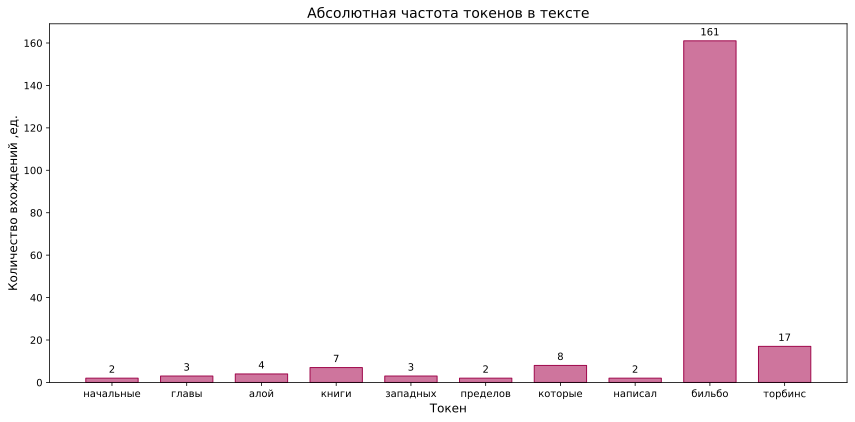

In [13]:
# берём срез данных
x = list(word_count.keys())[18:28]
y = list(word_count.values())[18:28]

# создаём график
plt.figure(figsize=(12, 6))
bars = plt.bar(x, y, color='#ce759d', align='center', edgecolor='#9e064a', width=0.7)

# аннотации по количеству вхождений каждого токена
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height + max(y) * 0.01, f'{int(height)}', ha='center', va='bottom', fontsize=10, color='black')

plt.title('Абсолютная частота токенов в тексте', fontsize=14)
plt.xlabel('Токен', fontsize=12)
plt.ylabel('Количество вхождений ,ед.', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

<a id=4.2.></a>
### 4.2. Создаём `TreeMap`
Визуализация относительного процента токенов в составе документа в виде сплошных занимаемых ими участков документа

In [14]:
# делаем срез топ-20 рангов из всего массива данных
wc_top20 = wc[wc['Ранг'] <= 20]

# подготовка данных: сортировка по убыванию процента
wc_top20 = wc_top20.sort_values('Доля от общего количества слов', ascending=False)

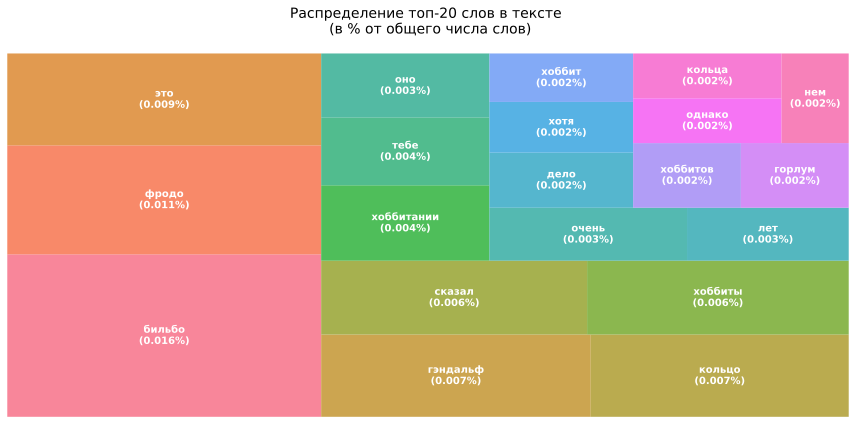

In [15]:
# создание согласованной цветовой палитры
colors = sns.color_palette('husl', n_colors=len(wc_top20))

# создание аннотаций: слово + процент его вхождений от всех слов
labels = [
    f"{word}\n({pct:.3f}%)"
    for word, pct in zip(wc_top20['Слово'], wc_top20['Доля от общего количества слов'])
]

# график типа TreeMap
plt.figure(figsize=(12, 6))
squarify.plot(
    sizes=wc_top20['Доля от общего количества слов'],
    label=labels,
    color=colors,
    alpha=0.85,
    text_kwargs={'fontsize': 10, 'weight': 'bold', 'color': 'white'})

plt.axis('off')
plt.title('Распределение топ-20 слов в тексте \n (в % от общего числа слов)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

<a id=4.3.></a>
### 4.3. Создаём и визуализируем облако слов

In [16]:
# из общего массива данных в работу берём слова и создаём из них сырой текст
data = wc['Слово'].reset_index()
text = ' '.join(data['Слово'])
text

'бильбо фродо это гэндальф кольцо сказал хоббиты хоббитании тебе оно очень лет дело хотя хоббит хоббитов горлум однако кольца нем всем время торбинс многие правда тех маг господин лишь жили день сказать знаю глаза никто знал горы те стал снова пор думал мое говорят говорили кому пока народ сэм подарки стали самые свое год просто кролы брендизайк старый гости однажды спросил эльфов долго вроде пусть оставил рождения девять жихарь стало чтото своим такие эльфы хоббита кольцом годы сто говорил отвечал словно мерри которые свой людей гномов крол четыре дни гостей мало вовсе жизни попрежнему запад давнымдавно реки хоббитам ибо сразу жизнь видно насчет жил несколько сколько пошел гэндальфа легче хочу книги которых нам вообще рукой нынче всей дней давно старого обычай свои ко слова дела собой среди свете кроме деле кармане горлума понял подарочек нашел взял слышал гномы дверь солнце поднялся оддо едва знаешь колец самых меньше нашей другие века какое когдато почему приречье говорить западного

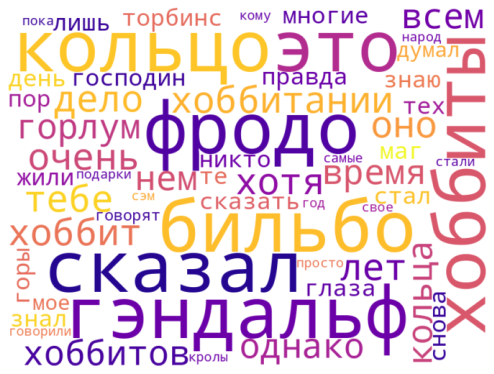

In [17]:
# визуализация: график `Word Cloud`
wordcloud = WordCloud(width=800, height=600, max_font_size=120, min_font_size=20, background_color='white', colormap='plasma', relative_scaling=0).generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [18]:
# сохраняем график в файл
wordcloud.to_file('wordcloud.png');

<a id=5></a>
## Шаг 5. Выводы

<br>Проект посвящён комплексной текстовой аналитике небольшого корпуса данных — текстового файла объёмом около 200 КБ, в нашем случае это «Властелин Колец» за авторством Дж.Р.Р. Толкина. Основная цель проекта — превратить неструктурированный текст в наглядную и количественно измеримую информацию, раскрывающую ключевые темы и частотные закономерности употребления слов.  
<br>На первом этапе выполняется загрузка текста и предварительная обработка: из него удаляются знаки препинания и стоп-слова (служебные слова, не несущие смысловой нагрузки, такие как «и», «в», «на» и т.п.), чтобы сосредоточиться на содержательной лексике. Затем реализуется алгоритм подсчёта частотности: для каждого уникального слова определяется, сколько раз оно встречается в тексте. На основе этих данных формируется структурированный датафрейм с четырьмя колонками: `Слово`, `Количество его вхождений`, `Ранг` (позиция в убывающем порядке частоты) и `Процент` — доля слова в общем количестве значимых слов текста.  
<br>Дальнейший этап проекта посвящён визуализации полученных результатов. Сначала строится `столбчатая диаграмма`, позволяющая быстро оценить самые частотные слова. Затем создаётся `TreeMap` — иерархическая диаграмма, где размер каждого блока пропорционален частоте соответствующего слова, что даёт интуитивное представление о распределении смысловых акцентов. Наконец, генерируется `Word Cloud` (облако слов), в котором наиболее употребительные термины отображаются крупнее, формируя визуальную «карту» ключевых тем текста.